# 01 — Quickstart: two-group t-test with TFNBS

Minimum viable ConnInfPy workflow: generate a small synthetic dataset
where group 2 has elevated connectivity inside one functional module,
run a two-sample **TFNBS** permutation test, and compare the detected
edges against the ground-truth mask.

Covers the core pipeline:

1. Generate connectivity matrices (`TopologyDatasetGenerator`).
2. Fisher-z transform (`fisher_r_to_z`).
3. Run `compute_p_val(..., method='tfnbs')`.
4. Threshold at p < 0.05 and score detections vs ground truth.

Runtime target: < 30 s.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from conninfpy import (
    TopologyDatasetGenerator,
    compute_p_val,
    fisher_r_to_z,
)

## 1. Generate synthetic data

`within_module_dense` plants a strong effect in the first module.
Use 40 nodes × 4 modules × 25 subjects per group.

In [8]:
N, n_modules, n_sub = 40, 4, 25
gen = TopologyDatasetGenerator(n_nodes=N, n_modules=n_modules, seed=0)
ds = gen.generate(
    "within_module_dense",
    effect_size=0.4,
    n_samples=n_sub,
    time_points=80,
)
group1_z = fisher_r_to_z(ds.group1)
group2_z = fisher_r_to_z(ds.group2)
print("group1_z:", group1_z.shape, " group2_z:", group2_z.shape)

group1_z: (25, 40, 40)  group2_z: (25, 40, 40)


## 2. Inspect the data

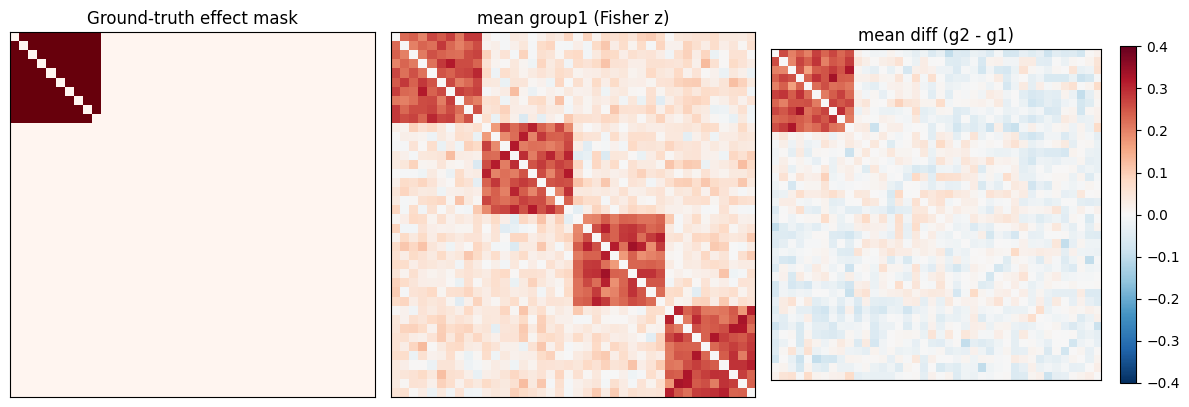

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(ds.effect_mask, cmap="Reds")
ax[0].set_title("Ground-truth effect mask")
ax[1].imshow(group1_z.mean(axis=0), cmap="RdBu_r", vmin=-0.5, vmax=0.5)
ax[1].set_title("mean group1 (Fisher z)")
im = ax[2].imshow(
    group2_z.mean(axis=0) - group1_z.mean(axis=0),
    cmap="RdBu_r", vmin=-0.4, vmax=0.4,
)
ax[2].set_title("mean diff (g2 - g1)")
for a in ax:
    a.set_xticks([]); a.set_yticks([])
fig.colorbar(im, ax=ax[2], fraction=0.046)
plt.tight_layout(); plt.show()

## 3. Run TFNBS permutation test

Two-sample test, 500 permutations. For a real analysis use 5000+ or
enable acceleration (see notebook 04).

In [4]:
%%time
p_vals = compute_p_val(
    group1_z, group2_z,
    test_type="two-sample",
    method="tfnbs",
    n_permutations=500,
    random_state=0,
    use_mp=False,
)
# Keys are 'g1>g2' / 'g2>g1' — the direction of the planted effect
# is group2 > group1, so we look at 'g2>g1'.
p_vals['g2>g1'].shape, p_vals['g1>g2'].shape

CPU times: user 712 ms, sys: 5.9 ms, total: 718 ms
Wall time: 718 ms


((40, 40), (40, 40))

## 4. Threshold and compare against ground truth

In [5]:
alpha = 0.05
sig = p_vals['g2>g1'] < alpha
gt = ds.effect_mask > 0

# Upper-triangle only so we count each edge once.
iu = np.triu_indices(N, k=1)
tp = int((sig[iu] & gt[iu]).sum())
fp = int((sig[iu] & ~gt[iu]).sum())
fn = int((~sig[iu] & gt[iu]).sum())
tn = int((~sig[iu] & ~gt[iu]).sum())
print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
print(f"Power (TPR) = {tp / max(tp + fn, 1):.3f}")
print(f"FPR         = {fp / max(fp + tn, 1):.3f}")

TP=45  FP=0  FN=0  TN=735
Power (TPR) = 1.000
FPR         = 0.000


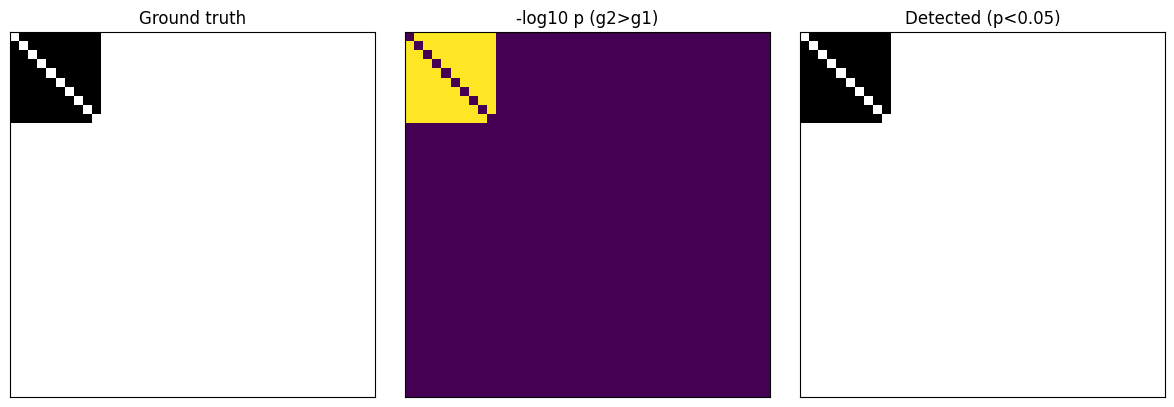

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gt, cmap="Greys"); ax[0].set_title("Ground truth")
ax[1].imshow(-np.log10(p_vals['g2>g1'] + 1e-6), cmap="viridis")
ax[1].set_title("-log10 p (g2>g1)")
ax[2].imshow(sig, cmap="Greys"); ax[2].set_title(f"Detected (p<{alpha})")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## Discussion

- `compute_p_val` always returns both tails (`g1>g2` / `g2>g1`).
  Enhancement is applied per tail, so positive and negative effects
  don't leak into each other.
- `method='tfnbs'` replaces the arbitrary-threshold step of classical
  NBS by integrating cluster support over many thresholds.
- For a parametric baseline (no permutation), use `method='bonferroni'`
  or `method='bh_fdr'`. For fixed-threshold NBS, use `method='nbs'`
  with a `threshold=` kwarg. See **notebook 02** for a side-by-side.